# Osnovni klasifokatori

In [ ]:
from sklearn import metrics, dummy
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [ ]:
iris = load_iris()
(iris_train_ftrs, iris_test_ftrs, iris_train_tgts, iris_test_tgts) = train_test_split(iris.data,
  iris.target, test_size=0.33, random_state=21)
baseline=dummy.DummyClassifier(strategy='most_frequent')
baseline.fit(iris_train_ftrs, iris_train_tgts)
baseline_preds=baseline.predict(iris_test_ftrs)
baseline_accuracy=metrics.accuracy_score(iris_test_tgts, baseline_preds)
print(f'Baseline accuracy: {baseline_accuracy}')

Baseline accuracy: 0.3


In [ ]:
import pandas as pd

strategies = ['constant', 'most_frequent', 'stratified', 'prior', 'uniform']

baseline_args = [{'strategy': s} for s in strategies]
baseline_args[0]['constant'] = 0
accuracies = []

for bla in baseline_args:
  baseline=dummy.DummyClassifier(**bla)
  baseline.fit(iris_train_ftrs, iris_train_tgts)
  baseline_preds=baseline.predict(iris_test_ftrs)
  accuracies.append(metrics.accuracy_score(iris_test_tgts, baseline_preds))
display(pd.DataFrame({'acc': accuracies}, index=strategies))

,acc
constant,0.36
most_frequent,0.30
stratified,0.34
prior,0.30
uniform,0.40


# Metrika za klasifikaciju - matrica konfuzije

In [ ]:
from sklearn import neighbors
from sklearn import metrics

iris = load_iris()

X=iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=21)
tgt_preds = (neighbors.KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train).predict(X_test))
#print(metrics.classification_report(y_test, tgt_preds))
cm = metrics.confusion_matrix(y_test, tgt_preds)
print(cm)

[[18  0  0]
 [ 0 15  2]
 [ 0  2 13]]


Text(20.72222222222222, 0.5, 'Actual')

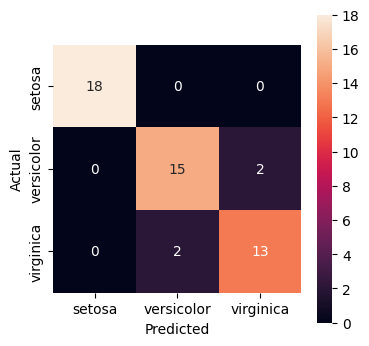

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(4,4))
cm=metrics.confusion_matrix(y_test, tgt_preds)
ax = sns.heatmap(cm, annot=True, square=True, xticklabels=iris.target_names, yticklabels=iris.target_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# Rad s višestrukim klasama

In [ ]:
from sklearn import neighbors
from sklearn import metrics
import numpy as np

iris = load_iris()

X=iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=21)
tgt_preds = (neighbors.KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train).predict(X_test))
#print(metrics.classification_report(y_test, tgt_preds))
cm = metrics.confusion_matrix(y_test, tgt_preds)
print(cm)

macro_precision = metrics.precision_score(y_test, tgt_preds, average='macro')
print('macro:', macro_precision)

n_labels = len(iris.target_names)
macro_precision = metrics.precision_score(y_test, tgt_preds, average='micro')

(np.diag(cm)/cm.sum(axis=0)).sum()/n_labels
#macro_recall = metrics.recall_score(y_test, tgt_preds, average='macro')

[[18  0  0]
 [ 0 15  2]
 [ 0  2 13]]
macro: 0.9163398692810457


np.float64(0.9163398692810457)

In [ ]:
micro_rec = metrics.precision_score(y_test, tgt_preds, average='micro')
print('micro:', micro_rec)

micro: 0.92


In [ ]:
print(metrics.classification_report(y_test, tgt_preds))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.88      0.88      0.88        17
           2       0.87      0.87      0.87        15

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



#ROC krivulje

In [ ]:
from sklearn.datasets import load_iris
from sklearn import naive_bayes
from sklearn import neighbors, metrics
from sklearn.model_selection import train_test_split
from sklearn import model_selection as skms
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

is_versicolor = (iris.target == 1)
tts_1c = skms.train_test_split(iris.data, is_versicolor, test_size=0.33, random_state=21)
(iris_1c_train_ftrs, iris_1c_test_ftrs, iris_1c_train_tgts, iris_1c_test_tgts) = tts_1c

gnb = naive_bayes.GaussianNB()
gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgts)
prob_true = gnb.predict_proba(iris_1c_test_ftrs)[:, 1]
print(prob_true)




[9.79865278e-01 4.50222228e-13 2.43026500e-16 1.96134602e-14
 9.52724313e-01 9.27725695e-01 3.87639359e-15 9.08785560e-03
 6.25366254e-13 2.86846833e-16 8.56437615e-01 9.58804822e-01
 1.80885105e-09 2.30342507e-14 7.70249873e-11 2.63886933e-01
 2.35755590e-01 9.61031568e-01 4.93114034e-20 4.99637540e-02
 3.19020482e-01 8.89388199e-01 7.87938780e-01 9.65605388e-01
 1.77131933e-17 3.93653599e-01 3.83266628e-16 1.66566751e-14
 9.79533423e-01 1.44515245e-06 5.14903222e-15 2.87187505e-11
 1.06081289e-01 2.48727276e-17 3.48004665e-01 9.37375446e-01
 3.94941566e-01 4.69745755e-08 4.67316571e-17 4.99637540e-02
 1.15989808e-01 2.20299432e-10 1.02490253e-02 9.71297885e-01
 1.50873250e-07 2.25970036e-17 2.59459411e-19 5.75243418e-20
 9.58230930e-01 4.68228921e-16]


FPR : [0.         0.         0.         0.06060606 0.06060606 0.12121212
 0.12121212 0.18181818 1.        ]
TPR : [0.         0.05882353 0.88235294 0.88235294 0.94117647 0.94117647
 1.         1.         1.        ]
[           inf 9.79865278e-01 3.93653599e-01 3.19020482e-01
 2.63886933e-01 1.15989808e-01 1.06081289e-01 4.99637540e-02
 4.93114034e-20]


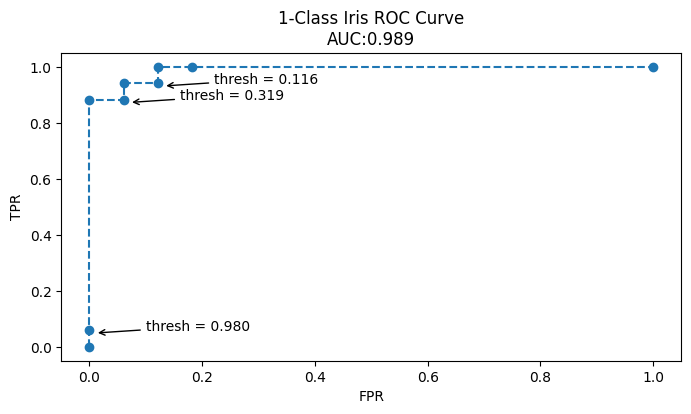

In [ ]:
fpr, tpr, thresh = metrics.roc_curve(iris_1c_test_tgts,
  prob_true)
auc = metrics.auc(fpr, tpr)
print("FPR : {}".format(fpr),
  "TPR : {}".format(tpr), sep='\n')
print(thresh)
# glavni graf
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fpr, tpr, 'o--')
ax.set_title("1-Class Iris ROC Curve\nAUC:{:.3f}".format(auc))
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");
# oznacavanje tocaka
investigate = np.array([1, 3, 5])
for idx in investigate:
  th, f, t = thresh[idx], fpr[idx], tpr[idx]
  ax.annotate('thresh = {:.3f}'.format(th),
    xy=(f+.01, t-.01), xytext=(f+.1, t),
    arrowprops = {'arrowstyle':'->'})